In [43]:
# ===============================
# CRISP-DM | Preparación de datos
# Paso: Carga de datos limpios diarios
# ===============================

import pandas as pd
from google.colab import files

# Subir archivo desde el equipo
uploaded = files.upload()

# Nombre del archivo (debe coincidir exactamente)
file_name = "datos_limpios_diarios_cacao_crispdm_preparacion.xlsx"

# Leer archivo Excel
df = pd.read_excel(file_name)

# Mostrar información general
df.info()

# Mostrar las primeras filas
df.head()


Saving datos_mensuales_cacao_crispdm_preparacion.xlsx to datos_mensuales_cacao_crispdm_preparacion (3).xlsx
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5293 entries, 0 to 5292
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Fecha          5293 non-null   datetime64[ns]
 1   Mes            5293 non-null   int64         
 2   Año            5293 non-null   int64         
 3   Día            5293 non-null   int64         
 4   PRECIPITACIÓN  5293 non-null   float64       
 5   TMAX           5293 non-null   float64       
 6   TMIN           5293 non-null   float64       
 7   TPROM          5293 non-null   float64       
 8   HR             5293 non-null   float64       
 9   RAD_SOL        5293 non-null   float64       
 10  EVPTRNS        5293 non-null   float64       
 11  VDL            5293 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(3)
memory usage: 496.3 KB


,Fecha,Mes,Año,Día,PRECIPITACIÓN,TMAX,TMIN,TPROM,HR,RAD_SOL,EVPTRNS,VDL
0,2010-01-01,1,2010,1,0.0,27.51,10.47,18.990,61.57,21.92,3.93,0.843932
1,2010-01-02,1,2010,2,0.0,28.04,12.77,20.405,58.46,21.59,3.33,0.995942
2,2010-01-03,1,2010,3,0.0,28.26,10.05,19.155,54.09,22.92,2.92,1.018620
3,2010-01-04,1,2010,4,0.0,27.82,12.38,20.100,50.96,21.90,2.43,1.153811
4,2010-01-05,1,2010,5,0.0,28.90,13.38,21.140,54.18,22.44,2.22,1.149382


## Documentación del proceso – Preparación y transformación de datos climáticos
# Metodología CRISP-DM
🔹 Descripción general del proceso ejecutado

En esta fase del proyecto se desarrolló la preparación y transformación de los datos climáticos, siguiendo la fase Data Preparation de la metodología CRISP-DM, con el objetivo de construir un conjunto de datos mensual, consistente y agronómicamente interpretable, que sirva como insumo para el análisis y modelado del cultivo de cacao en el municipio de San Vicente de Chucurí (Santander).

El proceso incluyó la validación de calidad, selección de variables relevantes, definición de reglas físicas y la agregación temporal de datos diarios a escala mensual.

| Etapa          | Actividad                        | Descripción                                                                             |
| -------------- | -------------------------------- | --------------------------------------------------------------------------------------- |
| Carga de datos | Lectura de dataset limpio diario | Se cargó el archivo `datos_limpios_diarios_cacao_crispdm_preparacion.xlsx`              |
| Validación     | Revisión de estructura y tipos   | Se verificó ausencia de valores nulos y tipos de datos correctos                        |
| Selección      | Variables climáticas             | Se trabajó con precipitación, temperatura, humedad, radiación, evapotranspiración y VDL |
| Transformación | Agregación mensual               | Se aplicaron reglas de suma o promedio según el significado físico                      |
| Resultado      | Dataset mensual                  | Se obtuvo una base con 174 registros mensuales (2010–2024)                              |


# Variables climáticas utilizadas y rangos óptimos para el cacao

A continuación se describen las variables climáticas seleccionadas, junto con sus rangos óptimos agronómicos, los cuales sustentan su inclusión en el modelo.


| Variable                   | Descripción                            | Rango óptimo para cacao |
| -------------------------- | -------------------------------------- | ----------------------- |
| **PRECIPITACIÓN (mm/mes)** | Acumulado mensual de lluvia            | 100 – 250 mm            |
| **TMAX (°C)**              | Temperatura máxima promedio mensual    | ≤ 32 °C                 |
| **TMIN (°C)**              | Temperatura mínima promedio mensual    | ≥ 18 °C                 |
| **TPROM (°C)**             | Temperatura media mensual              | 22 – 28 °C              |
| **HR (%)**                 | Humedad relativa promedio mensual      | 70 – 90 %               |
| **RAD_SOL (MJ/m²/día)**    | Radiación solar media mensual          | 16 – 22                 |
| **EVPTRNS (mm/mes)**       | Evapotranspiración potencial acumulada | < Precipitación         |
| **VDL (kPa)**              | Déficit de presión de vapor            | < 1.2 kPa               |


## Estrés Hídrico Mensual (EH)

El Estrés Hídrico Mensual (EH) es un índice agroclimático que representa la proporción de días dentro de un mes en los que la disponibilidad hídrica resulta insuficiente para el desarrollo adecuado del cultivo de cacao. Este indicador permite identificar periodos con potencial limitación hídrica, los cuales pueden afectar procesos fisiológicos clave del cultivo, como la floración, el cuajado de frutos y el llenado de mazorcas.

En el presente estudio, el estrés hídrico diario se define como una variable binaria, en la cual un día es clasificado como estresante cuando la precipitación diaria es inferior a un umbral mínimo de 1 mm. Este valor es comúnmente utilizado en estudios agroclimáticos en regiones tropicales para identificar días secos efectivos. A partir de esta variable diaria, el índice mensual se calcula como la razón entre el número de días con estrés hídrico y el total de días del mes correspondiente.

El Estrés Hídrico Mensual se calcula mediante la siguiente expresión:

EH_m = (Número de días con estrés hídrico en el mes) / (Número total de días del mes)

El índice EH toma valores entre 0 y 1, donde valores cercanos a 0 indican condiciones hídricas favorables y valores cercanos a 1 reflejan una alta frecuencia de días con déficit hídrico. Este indicador no tiene como objetivo la predicción de condiciones climáticas futuras, sino la caracterización y clasificación del comportamiento agroclimático histórico mensual, sirviendo como insumo para la generación de escenarios de apoyo a la planificación agrícola del cultivo de cacao.

In [44]:
# Distribución diaria de precipitación
df["PRECIPITACIÓN"].describe()


,PRECIPITACIÓN
count,5293.000000
mean,3.950104
std,10.431776
min,0.000000
25%,0.000000
50%,0.000000
75%,3.000000
max,189.000000


In [45]:
# Porcentaje de días con precipitación < 2 mm
(df["PRECIPITACIÓN"] < 2).mean() * 100


np.float64(69.22350273946722)

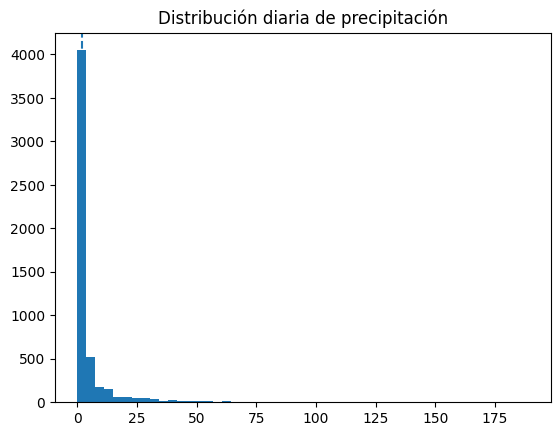

In [46]:
import matplotlib.pyplot as plt

plt.hist(df["PRECIPITACIÓN"], bins=50)
plt.axvline(2, linestyle="--")
plt.title("Distribución diaria de precipitación")
plt.show()


In [47]:
# ============================================================
# CÁLCULO DEL ÍNDICE DE ESTRÉS HÍDRICO (EH)
# Nivel diario → agregación mensual (metodología correcta)
# ============================================================

# ------------------------------------------------------------
# 1. Crear columna AÑO_MES
# ------------------------------------------------------------
df["AÑO_MES"] = df["Fecha"].dt.to_period("M")

df_mensual = (
    df.groupby("AÑO_MES")
      .agg(
          Fecha=("Fecha", "first")  # fecha representativa del mes
      )
      .reset_index()
)

# ------------------------------------------------------------
# 2. Estrés hídrico diario
# ------------------------------------------------------------
df["EH_dia"] = (df["PRECIPITACIÓN"] < 1).astype(int)

# ------------------------------------------------------------
# 3. Agregación mensual
# ------------------------------------------------------------
eh_mensual = (
    df.groupby("AÑO_MES")
      .agg(
          EH=("EH_dia", "mean"),
          Dias_mes=("EH_dia", "count")
      )
      .reset_index()
)

# ------------------------------------------------------------
# 4. Integración CORRECTA
# ------------------------------------------------------------
df_mensual = df_mensual.merge(
    eh_mensual,
    on="AÑO_MES",
    how="left"
)

# ------------------------------------------------------------
# 5. Limpieza final
# ------------------------------------------------------------
df_mensual.drop(columns=["AÑO_MES"], inplace=True)

# ------------------------------------------------------------
# 6. Validación
# ------------------------------------------------------------
display(df_mensual[["Fecha", "EH", "Dias_mes"]].head())
display(df_mensual["EH"].describe())


,Fecha,EH,Dias_mes
0,2010-01-01,0.935484,31
1,2010-02-01,0.607143,28
2,2010-03-01,0.612903,31
3,2010-04-01,0.633333,30
4,2010-05-01,0.516129,31


,EH
count,174.000000
mean,0.675659
std,0.135164
min,0.300000
25%,0.580645
50%,0.677995
75%,0.774194
max,0.935484


In [48]:
# ============================================================
# CREAR DATAFRAME MAESTRO DEL MODELO (a partir de EH)
# ============================================================

df_modelo_mensual = eh_mensual.copy()

# Verificación
df_modelo_mensual.head()


,AÑO_MES,EH,Dias_mes
0,2010-01,0.935484,31
1,2010-02,0.607143,28
2,2010-03,0.612903,31
3,2010-04,0.633333,30
4,2010-05,0.516129,31


In [49]:
df_modelo_mensual.columns


Index(['AÑO_MES', 'EH', 'Dias_mes'], dtype='object')

## Estrés térmico mensual (ET)

Con el propósito de cuantificar el impacto de condiciones térmicas adversas sobre el cultivo de cacao, se construyó la variable Estrés Térmico Mensual (ET), la cual mide la frecuencia de días con temperaturas extremas que pueden afectar el desarrollo fisiológico del cultivo. A diferencia de enfoques basados en desviaciones respecto a un valor óptimo central, en este estudio el estrés térmico se define a partir de umbrales críticos diarios, lo cual permite capturar de forma más realista la ocurrencia de eventos térmicos potencialmente dañinos.

A nivel diario, se considera que existe estrés térmico cuando la temperatura máxima diaria supera los 32 °C o cuando la temperatura mínima diaria es inferior a 15 °C, valores que corresponden a los límites de tolerancia fisiológica del cacao reportados en la literatura agroclimática. Bajo este criterio, cada día se clasifica mediante una variable binaria, donde 1 indica presencia de estrés térmico y 0 indica condiciones térmicas aceptables.

Posteriormente, el Estrés Térmico Mensual (ET) se calcula como la proporción de días del mes que presentan estrés térmico, agregando la información diaria a escala mensual. De esta forma, el índice ET toma valores continuos entre 0 y 1, donde valores cercanos a 0 representan meses con condiciones térmicas mayoritariamente favorables, mientras que valores cercanos a 1 indican meses dominados por condiciones térmicas adversas.

En el conjunto de datos final, esta variable se almacena en la columna ET, indexada por el período mensual (AÑO_MES), y constituye uno de los componentes fundamentales del Índice de Estrés Agroclimático Mensual del Cacao (IEAM-C), siendo utilizada como variable explicativa en las etapas posteriores de análisis y modelado con técnicas de machine learning.

Interpretación del Estrés Térmico Mensual (ET)
𝐸
𝑇
𝑚
∈
[
0
,
1
]
ET
m
	​

∈[0,1]

ET = 0: ningún día del mes presentó condiciones térmicas críticas

ET = 1: todos los días del mes presentaron estrés térmico

Para facilitar su interpretación agronómica, el Estrés Térmico Mensual se clasifica en los siguientes rangos:

| Rango ET    | Nivel de estrés térmico | Interpretación agronómica                                                |
| ----------- | ----------------------- | ------------------------------------------------------------------------ |
| 0.00 – 0.10 | Muy bajo                | Condiciones térmicas mayoritariamente óptimas                            |
| 0.11 – 0.30 | Bajo                    | Estrés térmico ocasional, sin impacto significativo                      |
| 0.31 – 0.60 | Moderado                | Estrés térmico recurrente, con posible afectación fisiológica            |
| 0.61 – 0.80 | Alto                    | Estrés térmico frecuente, con riesgo para floración y llenado de mazorca |
| 0.81 – 1.00 | Muy alto                | Condiciones térmicas adversas persistentes, alto riesgo agronómico       |

$$
ET_m = \frac{1}{D_m} \sum_{d=1}^{D_m} I\left( TMAX_d > 32 \;\lor\; TMIN_d < 15 \right)
$$

| Símbolo    | Descripción                                                          |
| ---------- | -------------------------------------------------------------------- |
| (ET_m)     | Índice de Estrés Térmico del mes (m)                                 |
| (D_m)      | Número total de días del mes (m)                                     |
| (TMAX_d)   | Temperatura máxima del día (d)                                       |
| (TMIN_d)   | Temperatura mínima del día (d)                                       |
| (I(\cdot)) | Función indicadora: 1 si se cumple la condición, 0 en caso contrario |


In [50]:
# ============================================================
# INTEGRACIÓN DEL ESTRÉS TÉRMICO (ET)
# ============================================================

# ------------------------------------------------------------
# 1. Asegurar clave Año-Mes en data diaria
# ------------------------------------------------------------
if "AÑO_MES" not in df.columns:
    df["AÑO_MES"] = df["Fecha"].dt.to_period("M")

# ------------------------------------------------------------
# 2. Estrés térmico diario
# Día crítico si:
#   - TMAX > 32 °C
#   - TMIN < 15 °C
# ------------------------------------------------------------
df["estres_termico_dia"] = (
    (df["TMAX"] > 32) | (df["TMIN"] < 15)
).astype(int)

# ------------------------------------------------------------
# 3. Agregación mensual de ET
# ------------------------------------------------------------
et_mensual = (
    df.groupby("AÑO_MES")
      .agg(
          ET=("estres_termico_dia", "mean")
      )
      .reset_index()
)

# ------------------------------------------------------------
# 4. Integrar ET al DataFrame maestro
# ------------------------------------------------------------
df_modelo_mensual = df_modelo_mensual.merge(
    et_mensual,
    on="AÑO_MES",
    how="left"
)

# ------------------------------------------------------------
# 5. (Opcional pero recomendado) Crear columna Fecha
# ------------------------------------------------------------
df_modelo_mensual["Fecha"] = df_modelo_mensual["AÑO_MES"].dt.to_timestamp()

# ------------------------------------------------------------
# 6. Verificación final
# ------------------------------------------------------------
df_modelo_mensual.head()
df_modelo_mensual[["EH", "ET"]].describe()


,EH,ET
count,174.000000,174.000000
mean,0.675659,0.165733
std,0.135164,0.163092
min,0.300000,0.000000
25%,0.580645,0.033333
50%,0.677995,0.118088
75%,0.774194,0.250000
max,0.935484,0.741935


## Estrés por Radiación Solar Mensual (ER)

El Estrés por Radiación Solar Mensual (ER) se define como la proporción de días dentro de un mes en los que la radiación solar diaria supera un umbral crítico, representando condiciones potencialmente adversas para el cultivo de cacao. Dado que el cacao es una especie adaptada a ambientes de sombra parcial, la exposición recurrente a niveles elevados de radiación solar puede inducir estrés fisiológico, aumentar la demanda evaporativa y afectar negativamente procesos clave como la fotosíntesis, la floración y el llenado de mazorca.

En este estudio, el estrés radiativo se evalúa a partir de valores absolutos de radiación solar diaria, considerando como día con estrés por radiación aquel en el que la radiación solar excede 22 MJ·m⁻²·día⁻¹, umbral ampliamente utilizado en literatura agroclimática para cultivos tropicales sensibles a la radiación directa. A nivel diario, esta condición se representa mediante una variable binaria, que toma el valor de 1 cuando se presenta estrés radiativo y 0 en caso contrario.

El índice ER mensual se calcula como el promedio de la variable diaria binaria para cada mes, lo cual equivale a la proporción de días con radiación solar excesiva respecto al total de días del mes. El índice ER adopta valores continuos entre 0 y 1, donde valores cercanos a 0 indican meses con condiciones radiativas mayormente favorables y valores cercanos a 1 reflejan una exposición persistente a radiación elevada.

ER_m = (1 / D_m) * Σ_d I(RAD_d > 22)




Donde:

ER_m : Estrés por Radiación Solar del mes m

D_m  : Número total de días del mes m

RAD_d : Radiación solar diaria (MJ·m⁻²·día⁻¹)

I(.) : Función indicadora (1 si se cumple la condición, 0 en caso contrario)



| Variable                | Valor / rango de referencia | Interpretación agronómica                 |
| ----------------------- | --------------------------- | ----------------------------------------- |
| Tipo de cultivo         | Sotobosque                  | Requiere sombra parcial                   |
| Exposición solar óptima | Moderada                    | Favorece fotosíntesis sin generar estrés  |
| Radiación solar crítica | > 22 MJ·m⁻²·día⁻¹           | Umbral de estrés radiativo diario         |
| Índice ER mensual       | 0 – 1                       | Proporción de días con radiación excesiva |


In [51]:
# ============================================================
# BLOQUE CONSOLIDADO: ESTRÉS POR RADIACIÓN SOLAR (ER)
# ============================================================

# ------------------------------------------------------------
# 1. Asegurar clave Año-Mes en data diaria
# ------------------------------------------------------------
if "AÑO_MES" not in df.columns:
    df["AÑO_MES"] = df["Fecha"].dt.to_period("M")

# ------------------------------------------------------------
# 2. Estrés por radiación diario
# Día crítico si la radiación solar excede 22 MJ/m²/día
# ------------------------------------------------------------
df["estres_radiacion_dia"] = (df["RAD_SOL"] > 22).astype(int)

# ------------------------------------------------------------
# 3. Agregación mensual de ER
# Proporción de días con estrés por radiación
# ------------------------------------------------------------
er_mensual = (
    df.groupby("AÑO_MES")
      .agg(
          ER=("estres_radiacion_dia", "mean")
      )
      .reset_index()
)

# ------------------------------------------------------------
# 4. Integrar ER al DataFrame maestro
# ------------------------------------------------------------
df_modelo_mensual = df_modelo_mensual.merge(
    er_mensual,
    on="AÑO_MES",
    how="left"
)

# ------------------------------------------------------------
# 5. Verificación rápida
# ------------------------------------------------------------
df_modelo_mensual[["AÑO_MES", "ER"]].head()
df_modelo_mensual["ER"].describe()


,ER
count,174.000000
mean,0.090727
std,0.090556
min,0.000000
25%,0.000000
50%,0.064516
75%,0.133333
max,0.419355


In [52]:
df_modelo_mensual.head()

,AÑO_MES,EH,Dias_mes,ET,Fecha,ER
0,2010-01,0.935484,31,0.419355,2010-01-01,0.129032
1,2010-02,0.607143,28,0.250000,2010-02-01,0.142857
2,2010-03,0.612903,31,0.161290,2010-03-01,0.064516
3,2010-04,0.633333,30,0.066667,2010-04-01,0.100000
4,2010-05,0.516129,31,0.064516,2010-05-01,0.032258


## Estrés por Evapotranspiración Potencial Mensual (EVPTRNS)

El Estrés por Evapotranspiración Potencial Mensual (EVPTRNS) se define como la proporción de días dentro de un mes en los que la demanda evaporativa atmosférica supera un umbral crítico para el cultivo de cacao, representando condiciones potenciales de estrés hídrico, aun en presencia de precipitación. La evapotranspiración potencial (ET₀) refleja la capacidad de la atmósfera para extraer agua del sistema suelo–planta, por lo que valores elevados de esta variable incrementan el riesgo de déficit hídrico, afectan la apertura estomática, reducen la eficiencia fotosintética y limitan el desarrollo fisiológico del cultivo.

En este estudio, el estrés por evapotranspiración se evalúa a partir de valores diarios de evapotranspiración potencial (EVPTRNS), considerando como día con estrés aquel en el que la evapotranspiración potencial diaria excede 4.0 mm·día⁻¹, umbral comúnmente empleado en estudios agroclimáticos para identificar condiciones de alta demanda evaporativa en cultivos tropicales perennes. A nivel diario, esta condición se representa mediante una variable binaria, que toma el valor de 1 cuando se presenta estrés por evapotranspiración y 0 en caso contrario.

El índice EVPTRNS mensual se calcula como el promedio de la variable diaria binaria para cada mes, lo cual equivale a la proporción de días con alta demanda evaporativa respecto al total de días del mes. Este índice adopta valores continuos entre 0 y 1, donde valores cercanos a 0 indican meses con baja presión evaporativa sobre el cultivo y valores cercanos a 1 reflejan una exposición persistente a condiciones de alta demanda atmosférica de agua.

$$
EVPTRNS_m = \frac{1}{D_m} \sum_{d=1}^{D_m} I(ET0_d > 4.0)
$$

Donde:

EVPTRNSₘ : Estrés por Evapotranspiración Potencial del mes m

Dₘ : Número total de días del mes m

ET0_d : Evapotranspiración potencial diaria (mm·día⁻¹)

I(·) : Función indicadora (1 si se cumple la condición, 0 en caso contrario)

In [53]:
# ============================================================
# CÁLCULO DEL ESTRÉS POR EVAPOTRANSPIRACIÓN (EVPTRNS)
# Nivel diario → agregación mensual → consolidación
# ============================================================

# 1. Asegurar columna Año-Mes
df["AÑO_MES"] = df["Fecha"].dt.to_period("M")

# 2. Estrés evapotranspirativo diario
# Rango óptimo cacao: 3–5 mm/día
df["estres_evptrns_dia"] = (
    (df["EVPTRNS"] < 3) | (df["EVPTRNS"] > 5)
).astype(int)

# 3. Agregación mensual
evptrns_mensual = (
    df.groupby("AÑO_MES")
      .agg(
          EVPTRNS=("estres_evptrns_dia", "mean"),
          Dias_mes=("estres_evptrns_dia", "count")
      )
      .reset_index()
)

# 4. Consolidar EVPTRNS en el DataFrame maestro
df_modelo_mensual = df_modelo_mensual.merge(
    evptrns_mensual[["AÑO_MES", "EVPTRNS"]],
    on="AÑO_MES",
    how="left"
)

# 5. Verificación rápida
df_modelo_mensual[["AÑO_MES", "EH", "ET", "ER", "EVPTRNS"]].head()
df_modelo_mensual["EVPTRNS"].describe()


,EVPTRNS
count,174.000000
mean,0.708515
std,0.178281
min,0.193548
25%,0.600000
50%,0.689286
75%,0.859677
max,1.000000


In [57]:
df_modelo_mensual.head()

,AÑO_MES,EH,Dias_mes,ET,Fecha,ER,EVPTRNS
0,2010-01,0.935484,31,0.419355,2010-01-01,0.129032,0.935484
1,2010-02,0.607143,28,0.250000,2010-02-01,0.142857,1.000000
2,2010-03,0.612903,31,0.161290,2010-03-01,0.064516,1.000000
3,2010-04,0.633333,30,0.066667,2010-04-01,0.100000,0.966667
4,2010-05,0.516129,31,0.064516,2010-05-01,0.032258,0.548387


In [55]:
df_modelo_mensual.describe()

,EH,Dias_mes,ET,Fecha,ER,EVPTRNS
count,174.000000,174.000000,174.000000,174,174.000000,174.000000
mean,0.675659,30.419540,0.165733,2017-04-29 01:06:12.413793024,0.090727,0.708515
min,0.300000,28.000000,0.000000,2010-01-01 00:00:00,0.000000,0.193548
25%,0.580645,30.000000,0.033333,2013-08-08 18:00:00,0.000000,0.600000
50%,0.677995,31.000000,0.118088,2017-03-16 12:00:00,0.064516,0.689286
75%,0.774194,31.000000,0.250000,2020-10-24 06:00:00,0.133333,0.859677
max,0.935484,31.000000,0.741935,2024-12-01 00:00:00,0.419355,1.000000
std,0.135164,0.827188,0.163092,NaN,0.090556,0.178281


## Estrés por Humedad Relativa Mensual (EHr)

El Estrés por Humedad Relativa Mensual (EHr) se define como la proporción de días dentro de un mes en los que la humedad relativa diaria se encuentra fuera del rango óptimo para el cultivo de cacao, representando condiciones potencialmente desfavorables para su desarrollo fisiológico. El cacao es una especie altamente sensible a variaciones extremas de humedad atmosférica, ya que niveles persistentemente bajos pueden incrementar la transpiración y el estrés hídrico, mientras que valores excesivamente altos favorecen la incidencia de enfermedades fúngicas y afectan procesos como la floración y la formación de frutos.

En este estudio, el estrés por humedad relativa se evalúa a partir de valores diarios de humedad relativa, considerando como día con estrés aquel en el que la humedad relativa es inferior al 70 % o superior al 90 %, rangos comúnmente reportados en la literatura agroclimática como límites funcionales para el cultivo de cacao. A nivel diario, esta condición se representa mediante una variable binaria, que toma el valor de 1 cuando se presenta estrés por humedad relativa y 0 cuando las condiciones son consideradas óptimas.

El índice EHr mensual se calcula como el promedio de la variable diaria binaria para cada mes, lo cual equivale a la proporción de días con humedad relativa fuera del rango óptimo respecto al total de días del mes. El índice EHr adopta valores continuos entre 0 y 1, donde valores cercanos a 0 indican meses con condiciones higrométricas mayormente favorables para el cultivo, mientras que valores cercanos a 1 reflejan una ocurrencia persistente de estrés por humedad relativa.

La formulación matemática del índice se expresa como:

$$
EHr_m = \frac{1}{D_m} \sum_{d=1}^{D_m} I(HR_d < 70 \; \lor \; HR_d > 90)
$$




Donde:

EHrₘ: Estrés por Humedad Relativa del mes m

Dₘ: Número total de días del mes m

HRₙ: Humedad relativa diaria (%)

I(·): Función indicadora (1 si se cumple la condición de estrés, 0 en caso contrario)

In [58]:
# ============================================================
# CÁLCULO DEL ESTRÉS POR HUMEDAD RELATIVA (EHr)
# Nivel diario → agregación mensual → consolidación
# ============================================================

# ------------------------------------------------------------
# 1. Asegurar columna AÑO_MES en ambos DataFrames
# ------------------------------------------------------------
df["AÑO_MES"] = df["Fecha"].dt.to_period("M")

if "AÑO_MES" not in df_modelo_mensual.columns:
    df_modelo_mensual["AÑO_MES"] = df_modelo_mensual["Fecha"].dt.to_period("M")

# ------------------------------------------------------------
# 2. Estrés por humedad relativa diario
# Criterio cacao: HR < 70 %
# ------------------------------------------------------------
df["estres_hr_dia"] = (df["HR"] < 70).astype(int)

# ------------------------------------------------------------
# 3. Agregación mensual
# EHr = proporción de días con HR baja
# ------------------------------------------------------------
ehr_mensual = (
    df.groupby("AÑO_MES")
      .agg(
          EHr=("estres_hr_dia", "mean"),
          Dias_mes=("estres_hr_dia", "count")
      )
      .reset_index()
)

# ------------------------------------------------------------
# 4. Consolidar EHr en el DataFrame maestro mensual
# ------------------------------------------------------------
df_modelo_mensual = df_modelo_mensual.merge(
    ehr_mensual[["AÑO_MES", "EHr"]],
    on="AÑO_MES",
    how="left"
)

# ------------------------------------------------------------
# 5. Limpieza opcional (si ya no necesitas AÑO_MES)
# ------------------------------------------------------------
# df_modelo_mensual.drop(columns=["AÑO_MES"], inplace=True)

# ------------------------------------------------------------
# 6. Validación
# ------------------------------------------------------------
display(df_modelo_mensual[["Fecha", "EHr"]].head())
display(df_modelo_mensual["EHr"].describe())


,Fecha,EHr
0,2010-01-01,1.000000
1,2010-02-01,0.892857
2,2010-03-01,0.548387
3,2010-04-01,0.200000
4,2010-05-01,0.000000


,EHr
count,174.000000
mean,0.191583
std,0.249081
min,0.000000
25%,0.000000
50%,0.065591
75%,0.322581
max,1.000000


## Cálculo del Estrés por Déficit de Presión de Vapor (VPD)

El estrés por déficit de presión de vapor (VPD) representa la demanda evaporativa de la atmósfera y constituye una de las variables más relevantes para evaluar el estrés hídrico en cultivos perennes como el cacao. Valores elevados de VPD indican una atmósfera más seca, lo que incrementa la transpiración de la planta y puede provocar cierre estomático, reducción de la fotosíntesis y afectaciones en el crecimiento y productividad del cultivo.

En este estudio, el VPD se calcula a partir de la variable base VDL, disponible a nivel diario, y se utiliza como indicador del gradiente de vapor entre la superficie foliar y la atmósfera. A nivel diario, se define una condición de estrés por VPD cuando el valor de VDL supera un umbral crítico, asociado a condiciones de alta demanda evaporativa para el cultivo de cacao.

La evaluación del estrés se realiza mediante una variable binaria diaria, que toma el valor de 1 cuando se presentan condiciones de estrés por VPD y 0 en caso contrario. Posteriormente, el índice mensual de estrés por VPD se obtiene como el promedio de esta variable diaria para cada mes, lo que equivale a la proporción de días con déficit de presión de vapor elevado respecto al total de días del mes.

El índice mensual de VPD adopta valores continuos entre 0 y 1, donde valores cercanos a 0 indican meses con condiciones atmosféricas mayormente favorables y valores cercanos a 1 reflejan una exposición persistente a alta demanda evaporativa, constituyendo un factor limitante para el desarrollo óptimo del cultivo de cacao.

El índice mensual de estrés por déficit de presión de vapor (VPD) se calcula como:

$$
VPD_m = \frac{1}{D_m} \sum_{d=1}^{D_m} I(VDL_d > VDL_{crit})
$$

donde:

- $VPD_m$: Estrés por déficit de presión de vapor del mes $m$  
- $D_m$: Número total de días del mes $m$  
- $VDL_d$: Déficit de presión de vapor diario  
- $VDL_{crit}$: Umbral crítico diario de déficit de presión de vapor  
- $I(\cdot)$: Función indicadora, que toma el valor de 1 si la condición se cumple y 0 en caso contrario


In [61]:
# ============================================================
# CÁLCULO DEL ESTRÉS POR DÉFICIT DE PRESIÓN DE VAPOR (VPD)
# Variable base: VDL
# Nivel diario → agregación mensual → consolidación
# ============================================================

# 1. Asegurar columna Año-Mes
df["AÑO_MES"] = df["Fecha"].dt.to_period("M")

# 2. Estrés por VPD diario
# Rango óptimo cacao: 0.5 – 1.2 kPa
df["estres_vpd_dia"] = (
    (df["VDL"] < 0.5) | (df["VDL"] > 1.2)
).astype(int)

# 3. Agregación mensual
vpd_mensual = (
    df.groupby("AÑO_MES")
      .agg(
          VPD=("estres_vpd_dia", "mean"),
          Dias_mes=("estres_vpd_dia", "count")
      )
      .reset_index()
)

# 4. Consolidar VPD en el DataFrame maestro
df_modelo_mensual = df_modelo_mensual.merge(
    vpd_mensual[["AÑO_MES", "VPD"]],
    on="AÑO_MES",
    how="left"
)

# 5. Verificación rápida
df_modelo_mensual[["AÑO_MES", "EH", "ET", "ER", "EVPTRNS", "EHr", "VPD"]].head()
df_modelo_mensual["VPD"].describe()


,VPD
count,174.000000
mean,0.461334
std,0.305844
min,0.000000
25%,0.195161
50%,0.416574
75%,0.709677
max,1.000000


In [62]:
df_modelo_mensual.describe()

,EH,Dias_mes,ET,Fecha,ER,EVPTRNS,EHr,VPD
count,174.000000,174.000000,174.000000,174,174.000000,174.000000,174.000000,174.000000
mean,0.675659,30.419540,0.165733,2017-04-29 01:06:12.413793024,0.090727,0.708515,0.191583,0.461334
min,0.300000,28.000000,0.000000,2010-01-01 00:00:00,0.000000,0.193548,0.000000,0.000000
25%,0.580645,30.000000,0.033333,2013-08-08 18:00:00,0.000000,0.600000,0.000000,0.195161
50%,0.677995,31.000000,0.118088,2017-03-16 12:00:00,0.064516,0.689286,0.065591,0.416574
75%,0.774194,31.000000,0.250000,2020-10-24 06:00:00,0.133333,0.859677,0.322581,0.709677
max,0.935484,31.000000,0.741935,2024-12-01 00:00:00,0.419355,1.000000,1.000000,1.000000
std,0.135164,0.827188,0.163092,NaN,0.090556,0.178281,0.249081,0.305844


## Ordenar DF

In [63]:
# ============================================================
# ORDENAR COLUMNAS DEL DATAFRAME FINAL
# ============================================================

orden_columnas = [
    "Fecha",
    "EH",
    "ET",
    "ER",
    "EVPTRNS",
    "EHr",
    "VPD",
    "Dias_mes"
]

# Reordenar el DataFrame
df_modelo_mensual = df_modelo_mensual[orden_columnas]

# Verificar resultado
df_modelo_mensual.head()


,Fecha,EH,ET,ER,EVPTRNS,EHr,VPD,Dias_mes
0,2010-01-01,0.935484,0.419355,0.129032,0.935484,1.000000,0.290323,31
1,2010-02-01,0.607143,0.250000,0.142857,1.000000,0.892857,0.428571,28
2,2010-03-01,0.612903,0.161290,0.064516,1.000000,0.548387,0.258065,31
3,2010-04-01,0.633333,0.066667,0.100000,0.966667,0.200000,0.500000,30
4,2010-05-01,0.516129,0.064516,0.032258,0.548387,0.000000,0.548387,31


##Análisis de correlación entre variables de estrés climático

La matriz de correlación evidencia relaciones coherentes entre los diferentes índices de estrés climático considerados en el estudio, reflejando tanto interacciones físicas entre variables atmosféricas como respuestas agroclimáticas esperadas para el cultivo de cacao.

El estrés hídrico (EH) presenta correlaciones positivas moderadas con ET (r = 0.33), ER (r = 0.21) y estrés por humedad relativa (EHr) (r = 0.27), lo cual sugiere que los periodos con mayor frecuencia de días secos tienden a coincidir con condiciones de mayor demanda evaporativa y mayor exposición radiativa. En contraste, se observa una correlación negativa moderada entre EH y VPD (r = −0.45), indicando que meses con mayor déficit de presión de vapor suelen asociarse con menor proporción de días secos, reflejando la compleja interacción entre disponibilidad hídrica y demanda atmosférica.

El estrés por radiación solar (ER) muestra una correlación positiva moderada con EHr (r = 0.43), lo que sugiere que periodos de alta radiación tienden a coincidir con condiciones de humedad relativa fuera del rango óptimo para el cacao. Asimismo, ER presenta una correlación negativa con VPD (r = −0.52), consistente con escenarios en los que una mayor humedad atmosférica reduce el déficit de presión de vapor aun bajo condiciones de alta radiación.

Por su parte, el índice de estrés por evapotranspiración (EVPTRNS) exhibe una correlación positiva relativamente alta con EHr (r = 0.53), indicando que condiciones de evapotranspiración fuera del rango óptimo suelen coincidir con niveles no ideales de humedad relativa. En contraste, su correlación con ET y ER es baja, lo que sugiere que EVPTRNS captura un componente diferenciado del estrés climático, asociado principalmente al balance hídrico-atmosférico.

Finalmente, el índice VPD presenta correlaciones negativas con la mayoría de las variables, destacándose su fuerte relación inversa con EHr (r = −0.62) y ER (r = −0.52). Este comportamiento es consistente con el fundamento físico del déficit de presión de vapor, el cual aumenta cuando la humedad relativa disminuye y la atmósfera presenta mayor capacidad de extracción de agua desde el cultivo.

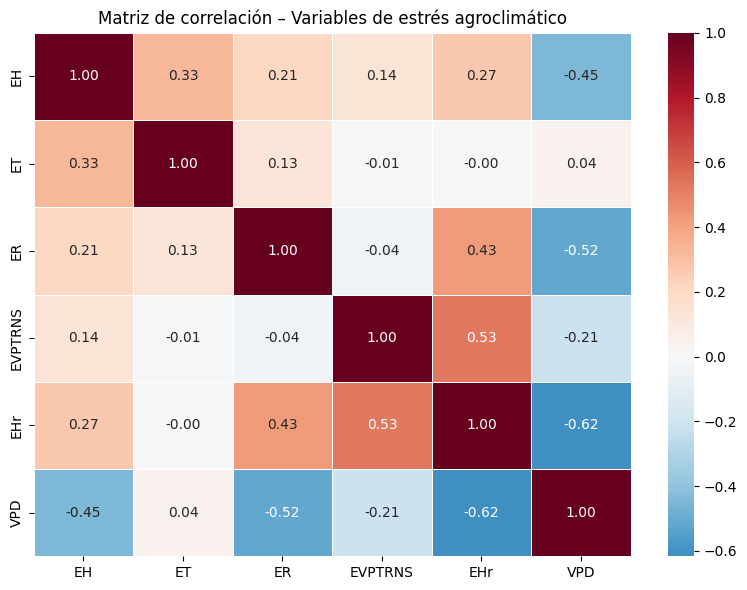

,EH,ET,ER,EVPTRNS,EHr,VPD
EH,1.000000,0.331699,0.205885,0.139900,0.273473,-0.451614
ET,0.331699,1.000000,0.129399,-0.013039,-0.001426,0.041841
ER,0.205885,0.129399,1.000000,-0.036902,0.427160,-0.516171
EVPTRNS,0.139900,-0.013039,-0.036902,1.000000,0.527343,-0.212350
EHr,0.273473,-0.001426,0.427160,0.527343,1.000000,-0.616968
VPD,-0.451614,0.041841,-0.516171,-0.212350,-0.616968,1.000000


In [64]:
# ============================================================
# MATRIZ DE CORRELACIÓN – VARIABLES DE ESTRÉS AGROCLIMÁTICO
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar variables de estrés
vars_estres = ["EH", "ET", "ER", "EVPTRNS", "EHr", "VPD"]

df_corr = df_modelo_mensual[vars_estres]

# Calcular matriz de correlación (Pearson)
corr_matrix = df_corr.corr(method="pearson")

# Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)
plt.title("Matriz de correlación – Variables de estrés agroclimático")
plt.tight_layout()
plt.show()

# Mostrar matriz numérica
corr_matrix


## Estrés Agroclimático Mensual del Cacao (IEAM-C)

El Índice de Estrés Agroclimático Mensual del Cacao (IEAM-C) se define como una medida compuesta que integra múltiples factores climáticos relevantes para el desarrollo fisiológico del cultivo de cacao, con el propósito de caracterizar de forma sintética el nivel de estrés agroclimático al que se encuentra expuesto el cultivo en cada mes del período de estudio.

Este índice combina los efectos del estrés hídrico (EH), estrés térmico (ET), estrés por radiación solar (ER), estrés por evapotranspiración (EVPTRNS), estrés por humedad relativa (EHr) y estrés por déficit de presión de vapor (VPD), variables que representan distintos mecanismos de interacción entre la atmósfera, el suelo y la planta. Cada una de estas variables se construye previamente a nivel diario mediante funciones indicadoras basadas en umbrales agronómicos específicos para el cacao y posteriormente se agrega a escala mensual como la proporción de días con condiciones de estrés.

El IEAM-C se calcula como una combinación lineal ponderada de los índices de estrés individuales, donde los pesos asignados reflejan tanto la importancia agronómica de cada variable como los resultados del análisis de correlación, evitando redundancias y priorizando los factores con mayor impacto sobre la fisiología del cultivo. De esta forma, se otorga mayor peso relativo a variables asociadas a la demanda evaporativa y al balance hídrico-atmosférico, como EVPTRNS y VPD, y un peso moderado a los índices de ET, ER y EHr.

El índice IEAM-C adopta valores continuos entre 0 y 1, donde valores cercanos a 0 indican meses con condiciones agroclimáticas mayormente favorables para el cultivo de cacao, mientras que valores cercanos a 1 reflejan una exposición persistente a condiciones de estrés climático. Este enfoque permite comparar de manera homogénea el comportamiento agroclimático entre meses y constituye una herramienta de apoyo para la planificación agrícola, facilitando la identificación de periodos críticos y la toma de decisiones orientadas a la adaptación frente a la variabilidad climática.

IEAM_C_m = 0.25·EH_m + 0.10·ET_m + 0.10·ER_m + 0.10·EHr_m + 0.20·EVPTRNS_m + 0.25·VPD_m

Donde:

IEAM_Cₘ : Índice de Estrés Agroclimático del mes m

EHₘ : Estrés hídrico mensual (proporción de días secos)

ETₘ : Estrés térmico mensual

ERₘ : Estrés por radiación solar mensual

EHrₘ : Estrés por humedad relativa mensual

EVPTRNSₘ : Estrés por evapotranspiración mensual

VPDₘ : Estrés por déficit de presión de vapor mensual

In [65]:
# ============================================================
# CÁLCULO DEL ÍNDICE DE ESTRÉS AGROCLIMÁTICO MENSUAL DEL CACAO
# IEAM-C
# ============================================================

# Pesos definidos a partir del análisis de correlación
w_EH = 0.25       # Estrés hídrico
w_ET = 0.10       # Estrés térmico
w_ER = 0.10       # Estrés por radiación solar
w_EHr = 0.10      # Estrés por humedad relativa
w_EVPTRNS = 0.20  # Estrés por evapotranspiración
w_VPD = 0.25      # Déficit de presión de vapor

# Verificación rápida de columnas necesarias
vars_ieam = ["EH", "ET", "ER", "EHr", "EVPTRNS", "VPD"]
missing = [v for v in vars_ieam if v not in df_modelo_mensual.columns]

if missing:
    raise ValueError(f"Faltan variables para calcular IEAM-C: {missing}")

# Cálculo del índice IEAM-C
df_modelo_mensual["IEAM_C"] = (
    w_EH * df_modelo_mensual["EH"] +
    w_ET * df_modelo_mensual["ET"] +
    w_ER * df_modelo_mensual["ER"] +
    w_EHr * df_modelo_mensual["EHr"] +
    w_EVPTRNS * df_modelo_mensual["EVPTRNS"] +
    w_VPD * df_modelo_mensual["VPD"]
)

# Verificación estadística
df_modelo_mensual["IEAM_C"].describe()


,IEAM_C
count,174.000000
mean,0.470756
std,0.072058
min,0.246667
25%,0.426022
50%,0.472581
75%,0.514220
max,0.685484


In [66]:
df_modelo_mensual.head()

,Fecha,EH,ET,ER,EVPTRNS,EHr,VPD,Dias_mes,IEAM_C
0,2010-01-01,0.935484,0.419355,0.129032,0.935484,1.000000,0.290323,31,0.648387
1,2010-02-01,0.607143,0.250000,0.142857,1.000000,0.892857,0.428571,28,0.587500
2,2010-03-01,0.612903,0.161290,0.064516,1.000000,0.548387,0.258065,31,0.495161
3,2010-04-01,0.633333,0.066667,0.100000,0.966667,0.200000,0.500000,30,0.513333
4,2010-05-01,0.516129,0.064516,0.032258,0.548387,0.000000,0.548387,31,0.385484


In [67]:
df_modelo_mensual.describe()

,Fecha,EH,ET,ER,EVPTRNS,EHr,VPD,Dias_mes,IEAM_C
count,174,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000
mean,2017-04-29 01:06:12.413793024,0.675659,0.165733,0.090727,0.708515,0.191583,0.461334,30.419540,0.470756
min,2010-01-01 00:00:00,0.300000,0.000000,0.000000,0.193548,0.000000,0.000000,28.000000,0.246667
25%,2013-08-08 18:00:00,0.580645,0.033333,0.000000,0.600000,0.000000,0.195161,30.000000,0.426022
50%,2017-03-16 12:00:00,0.677995,0.118088,0.064516,0.689286,0.065591,0.416574,31.000000,0.472581
75%,2020-10-24 06:00:00,0.774194,0.250000,0.133333,0.859677,0.322581,0.709677,31.000000,0.514220
max,2024-12-01 00:00:00,0.935484,0.741935,0.419355,1.000000,1.000000,1.000000,31.000000,0.685484
std,NaN,0.135164,0.163092,0.090556,0.178281,0.249081,0.305844,0.827188,0.072058


In [68]:
import numpy as np

# Función de clasificación del IEAM-C
def clasificar_ieam(valor):
    if valor < 0.40:
        return "Favorable"
    elif valor < 0.48:
        return "Estrés leve"
    elif valor < 0.56:
        return "Estrés moderado"
    else:
        return "Estrés alto"

# Crear columna de clasificación
df_modelo_mensual["Clasificacion_IEAM_C"] = df_modelo_mensual["IEAM_C"].apply(clasificar_ieam)

# Verificar resultados
df_modelo_mensual[["Fecha", "IEAM_C", "Clasificacion_IEAM_C"]].head()


,Fecha,IEAM_C,Clasificacion_IEAM_C
0,2010-01-01,0.648387,Estrés alto
1,2010-02-01,0.587500,Estrés alto
2,2010-03-01,0.495161,Estrés moderado
3,2010-04-01,0.513333,Estrés moderado
4,2010-05-01,0.385484,Favorable


In [70]:
# ============================================================
# EXPORTAR Y DESCARGAR DATASET FINAL (GOOGLE COLAB)
# ============================================================

from google.colab import files

# 1. Nombres de archivos
archivo_excel = "IEAM_C_Cacao_San_Vicente_Modelo.xlsx"
archivo_csv   = "IEAM_C_Cacao_San_Vicente_Modelo.csv"

# 2. Exportar archivos
df_modelo_mensual.to_excel(
    archivo_excel,
    index=False
)

df_modelo_mensual.to_csv(
    archivo_csv,
    index=False,
    encoding="utf-8"
)

# 3. Descargar automáticamente
files.download(archivo_excel)
files.download(archivo_csv)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>